In [2]:
import glob
import os
import sys
import datetime
import argparse
import copy
from pathlib import Path
import xarray as xr
from scipy.stats import binned_statistic_2d
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import numpy as np
import netCDF4 as nc
import matplotlib as mpl

# Bin edges and midpoints
lat_edges = np.arange(-90, 91, 1)
lon_edges = np.arange(-180, 181, 1)
lat_mids = lat_edges[:-1] + 0.5
lon_mids = lon_edges[:-1] + 0.5

In [3]:
ds = xr.load_dataset('../data/sat1_0125.zarr')
ds

<xarray.Dataset> Size: 82MB
Dimensions:                  (lat: 180, lon: 360, spectral: 63)
Coordinates:
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 88.0 89.0
  * lon                      (lon) float64 3kB -180.0 -179.0 ... 178.0 179.0
  * spectral                 (spectral) int64 504B 0 1 2 3 4 ... 58 59 60 61 62
Data variables:
    spectral_radiance        (lat, lon, spectral) float32 16MB nan nan ... nan
    spectral_radiance_count  (lat, lon, spectral) int32 16MB 0 0 0 0 ... 0 0 0 0
    spectral_radiance_max    (lat, lon, spectral) float32 16MB 0.0 0.0 ... 0.0
    spectral_radiance_min    (lat, lon, spectral) float32 16MB inf inf ... inf
    spectral_radiance_std    (lat, lon, spectral) float32 16MB nan nan ... nan
    wavelength               (spectral) float32 252B nan nan nan ... 51.9 52.66
Attributes:
    description:  Gridded mean, std, count, min, max of spectral radiance bin...
    satellite:    sat1
    year_month:   2025-01

In [12]:
ds = xr.load_dataset('../data/2512RADdeg.nc')

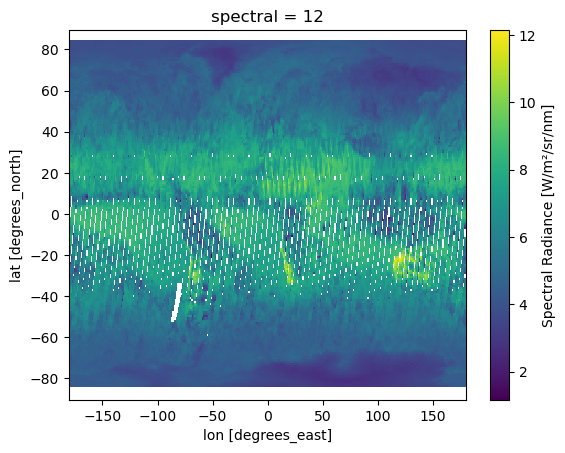

In [13]:
ds.spectral_radiance.isel(spectral = 12).plot()

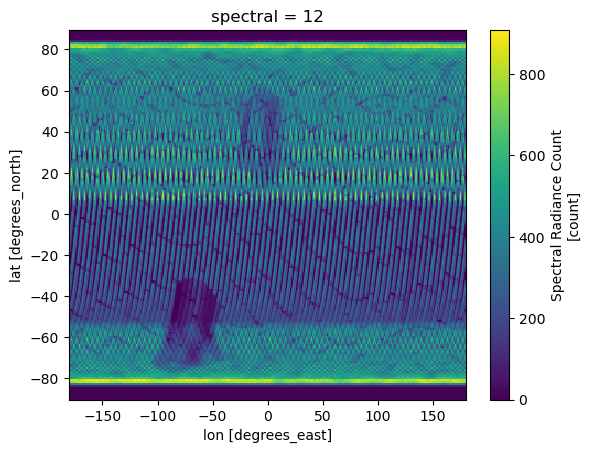

In [15]:
ds.spectral_radiance_count.isel(spectral = 12).plot()

In [25]:
def get_statistic_display_name(statistic_name):
    """Convert statistic name to display name."""
    names = {
        'mean': 'Mean Spectral Radiance',
        'min': 'Min Spectral Radiance',
        'max': 'Max Spectral Radiance',
        'std': 'Standard Deviation of Spectral Radiance'
    }
    return names.get(statistic_name, statistic_name.capitalize())
def create_orthographic_plot(
    data, 
    statistic_name, 
    pole, 
    wavelength, 
    output_path,
    # count_mask,
    satellite,
    season,
    vmin=None,
    vmax=None,
    cmap='inferno'
):
    """
    Create an orthographic projection plot for North or South Pole.
    
    Parameters:
    -----------
    data : array
        2D array of data to plot
    statistic_name : str
        Name of statistic ('mean', 'min', 'max', 'std')
    pole : str
        'north' or 'south'
    wavelength : float
        Wavelength in micrometers
    output_path : str
        Full path to save the plot
    count_mask : array
        2D boolean array for hatching areas with low counts
    satellite : str
        Satellite name (SAT1 or SAT2)
    season : str
        Season name (SON, DJF, MAM, JJA)
    vmin, vmax : float
        Color scale limits
    cmap : str
        Colormap name
    """
    mpl.rcParams['hatch.linewidth'] = 0.3
    
    # Determine projection center and extent based on pole
    if pole == 'north':
        central_lat = 90
        central_lon = 0
        extent = [-180, 180, 60, 90]
        lat_range = np.arange(60, 91, 10)
        lat_label_range = np.arange(70, 90, 10)  # Exclude 90°N
        circle_lats = [70, 80]
        lat_suffix = 'N'
    else:  # south
        central_lat = -90
        central_lon = 0
        extent = [-180, 180, -60, -90]
        lat_range = np.arange(-60, -90, -10)
        lat_label_range = np.arange(-70, -90, -10)
        circle_lats = [-70, -80]
        lat_suffix = 'S'
    
    # Create meshgrid
    lon2d, lat2d = np.meshgrid(lon_mids, lat_mids)
    
    # Create figure and axis
    plt.figure(figsize=(10, 10))
    ax = plt.axes([0, 0, 1, 1], projection=ccrs.Orthographic(
        central_latitude=central_lat, 
        central_longitude=central_lon
    ))
    
    # Plot the data
    # Change the colorbar setting here
    
    mesh = ax.pcolormesh(
        lon2d, lat2d, data,
        cmap=cmap, 
        shading='auto',
        transform=ccrs.PlateCarree(),
        vmin=vmin, 
        vmax=vmax
    )
    
    # Add hatching over areas with low counts
    # hatch_overlay = ax.contourf(
    #     lon2d, lat2d, count_mask.astype(float),
    #     levels=[0.5, 1.5], 
    #     hatches=['...'],   
    #     colors='none',
    #     transform=ccrs.PlateCarree()
    # )
    
    # Add coastlines and features
    ax.coastlines()
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    
    # Add latitude circles
    for lat in circle_lats:
        circle = plt.Circle((0, 0), abs(90 - abs(lat))/30, fill=False, 
                           color='white', alpha=0.5, linestyle=':')
        ax.add_patch(circle)
    
    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=1, color='white', alpha=0.7)
    gl.xlabel_style = {'size': 11, 'color': 'black', 'weight': 'bold'}
    gl.ylabel_style = {'size': 11, 'color': 'black', 'weight': 'bold'}
    gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = plt.FixedLocator(lat_range)
    
    # Add latitude labels
    for lat in lat_label_range:
        proj_coords = ax.projection.transform_point(0, lat, ccrs.PlateCarree())
        if ax.get_xlim()[0] <= proj_coords[0] <= ax.get_xlim()[1]:
            ax.text(
                0, lat, f"{abs(lat)}°{lat_suffix}",
                transform=ccrs.PlateCarree(),
                ha='left', va='center',
                fontsize=11, fontweight='bold',
                color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7)
            )
    
    # Set circular boundary
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpl.path.Path(verts*radius+center)
    ax.set_boundary(circle, transform=ax.transAxes)
    
    # Set title
    pole_name = "North" if pole == 'north' else "South"
    statistic_display = get_statistic_display_name(statistic_name)
    ax.set_title(f"{satellite} {wavelength}µm {statistic_display}\n{pole_name} Pole - {season}", 
                 fontsize=17)
    
    # Add colorbar
    cbar = plt.colorbar(mesh, shrink=0.7, pad=0.05, aspect=30)
    cbar.set_label("Brightness Temperature (K)", fontsize=15, labelpad=15)
    if vmin is not None and vmax is not None:
        cbar.set_ticks(np.linspace(vmin, vmax, 5))  # 5 evenly spaced ticks including vmin and vmax
    cbar.ax.tick_params(labelsize=12)
    
    # Save plot
    # plt.savefig(output_path, dpi=150, bbox_inches='tight')
    # plt.close()
    print(f"Saved: {output_path}")

In [ ]:
import numpy as np


1.0

Saved: ../public/sr_pics/trial/trial
Saved: ../public/sr_pics/trial/trial
Saved: ../public/sr_pics/trial/trial
Saved: ../public/sr_pics/trial/trial
Saved: ../public/sr_pics/trial/trial


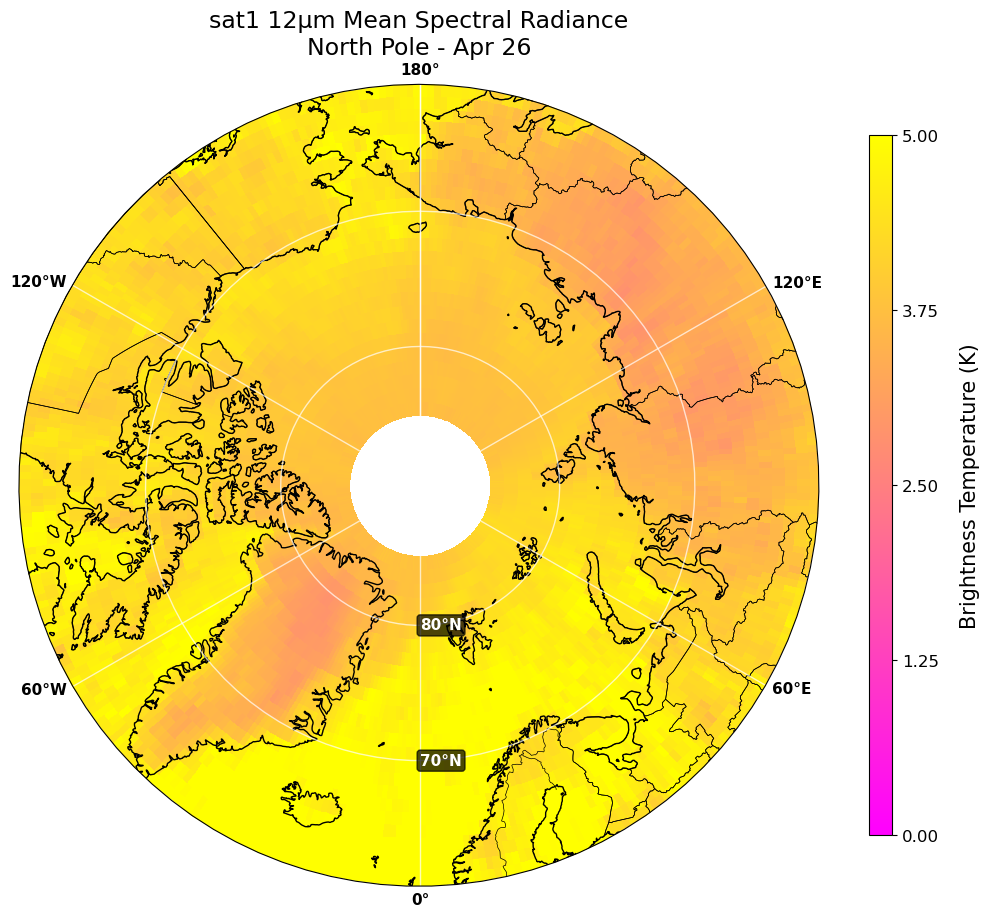

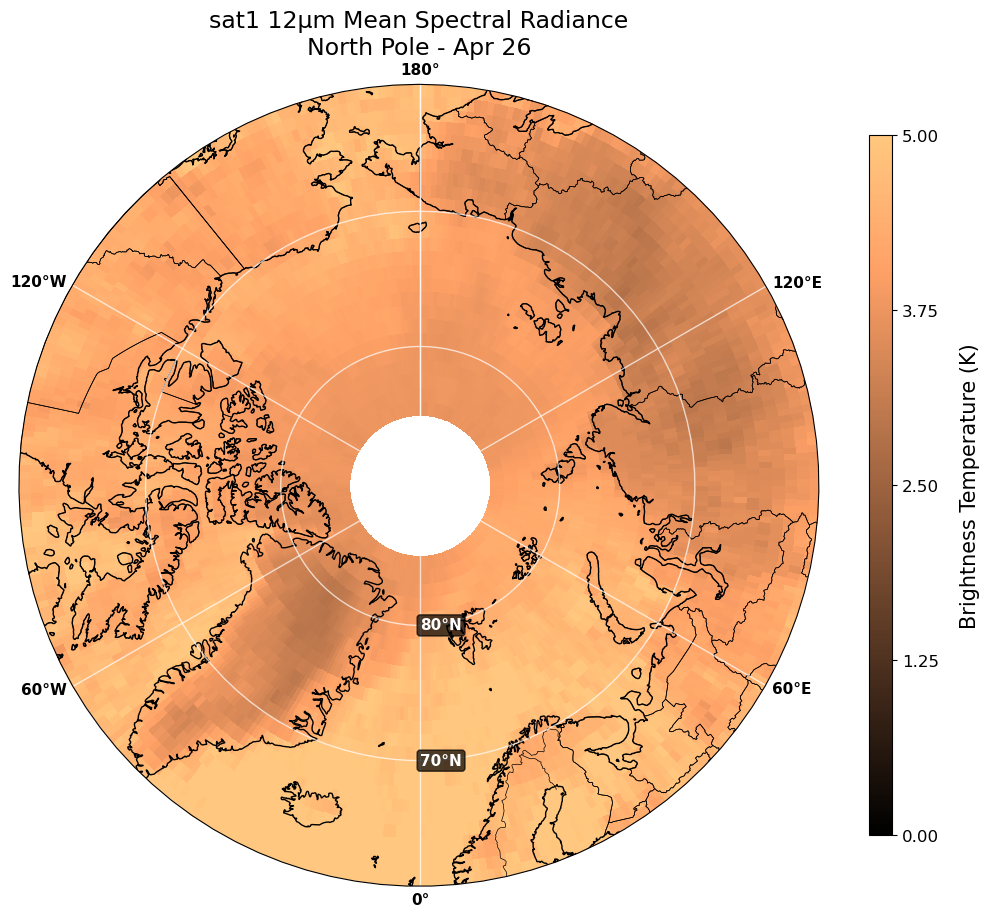

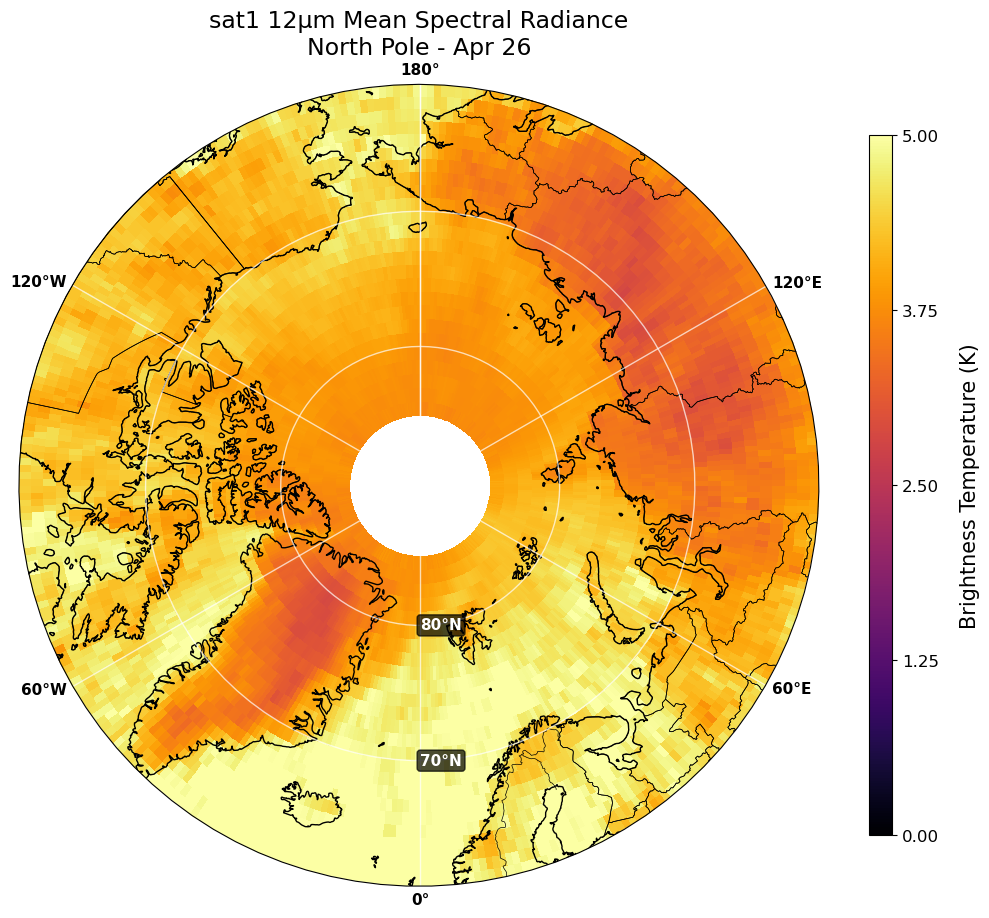

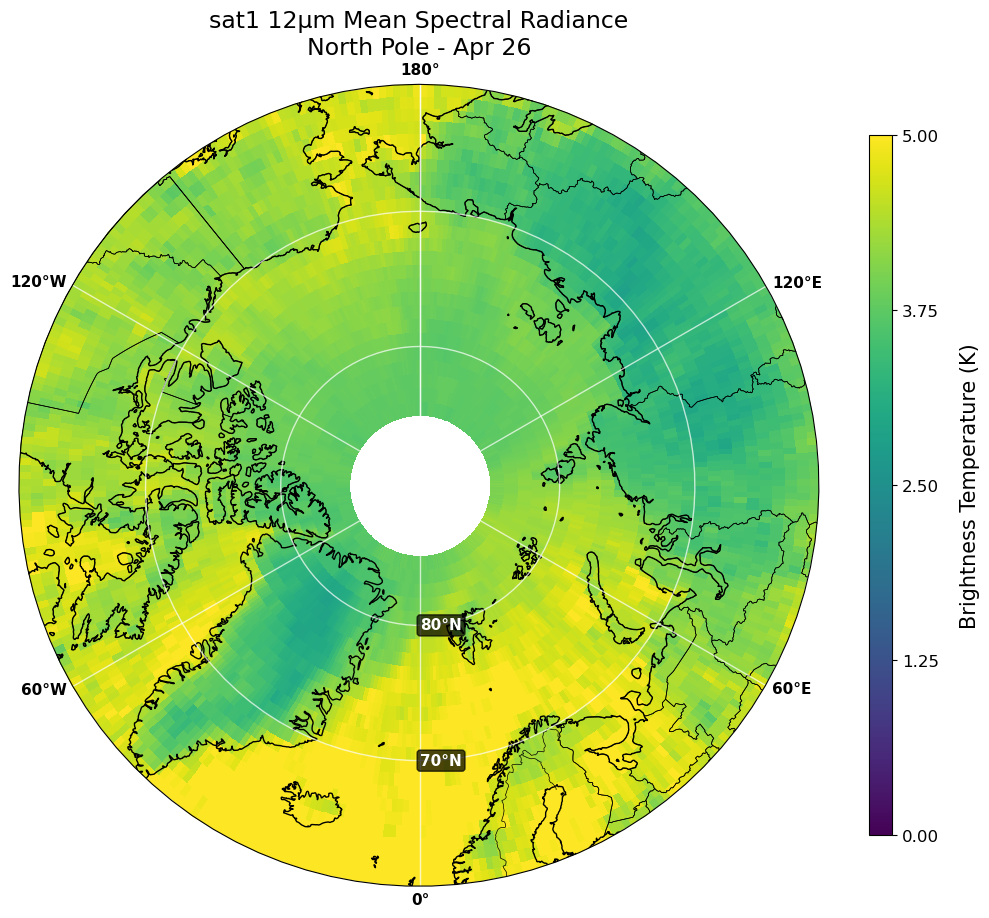

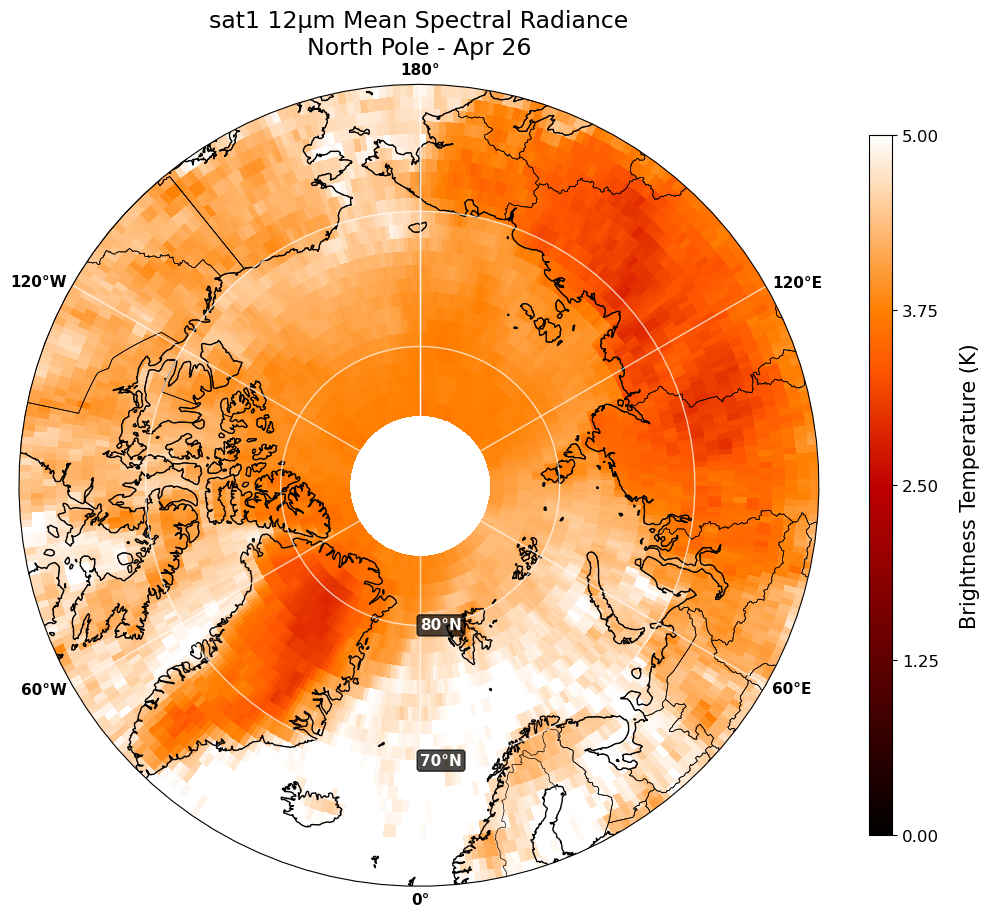

In [ ]:
spec_num = 12
for cmaps in [ 'spring', 'copper', 'inferno', 'viridis', 'gist_heat']:
    create_orthographic_plot(
        ds.spectral_radiance.isel(spectral = spec_num), 'mean', 'north', ds.spectral.values[spec_num], '../public/sr_pics/trial/trial',
        'sat1',
        'Apr 26',
        vmin=0,  
        vmax=5,
        cmap=cmaps)